In [1]:
# Habilitar visualización de gráficos en el notebook
%matplotlib inline

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import holidays

In [5]:
import streamlit as st

In [6]:
# Definir rutas relativas correctas
ventas_path = '../data/raw/entrenamiento/ventas.csv'
competencia_path = '../data/raw/entrenamiento/competencia.csv'  

# Cargar los archivos CSV en dataframes
import pandas as pd
ventas_df = pd.read_csv(ventas_path)
competencia_df = pd.read_csv(competencia_path)

# Mostrar las primeras filas para verificar
print(ventas_df.head())
print(competencia_df.head())

        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         75.42    150.84  


In [7]:
ventas_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


### Elasticidad básica precio-volumen

- Se realiza un scatter plot de precio vs unidades vendidas.
- Se calcula la correlación entre precio y unidades para detectar sensibilidad al precio.
- Si existe una relación negativa significativa, los productos son sensibles al precio.

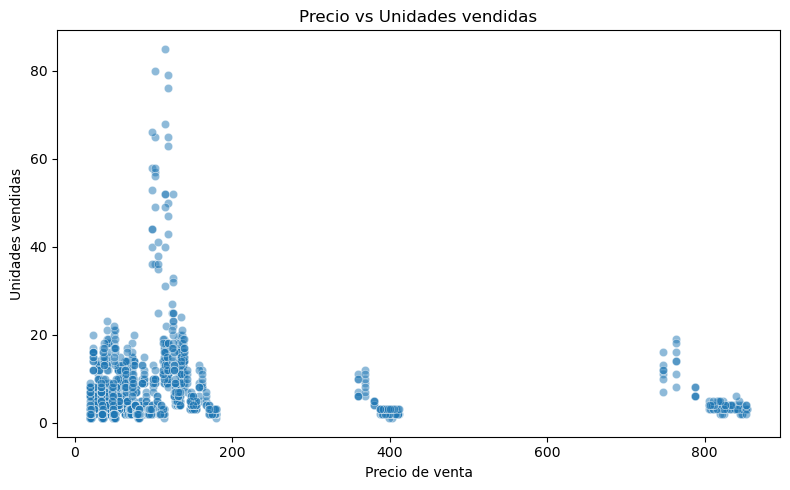

Correlación precio-unidades: 0.00
No se observa sensibilidad significativa al precio.


In [50]:
# Elasticidad básica precio-volumen y sensibilidad al precio
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['precio_venta'], y=df['unidades_vendidas'], alpha=0.5)
plt.title('Precio vs Unidades vendidas')
plt.xlabel('Precio de venta')
plt.ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()
correlacion = df[['precio_venta', 'unidades_vendidas']].corr().iloc[0,1]
print(f'Correlación precio-unidades: {correlacion:.2f}')
if correlacion < -0.2:
    print('Existe sensibilidad negativa al precio: a mayor precio, menos ventas.')
else:
    print('No se observa sensibilidad significativa al precio.')

In [51]:
competencia_df.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [52]:
ventas_df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='object')

In [53]:
competencia_df.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='object')

### Boxplot de precios y unidades vendidas (detección de outliers)

- Se visualizan los outliers en precios y unidades vendidas mediante boxplots.
- Permite identificar productos atípicos que pueden requerir revisión o estrategias diferenciadas.

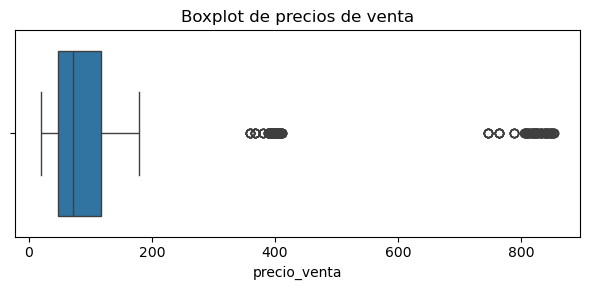

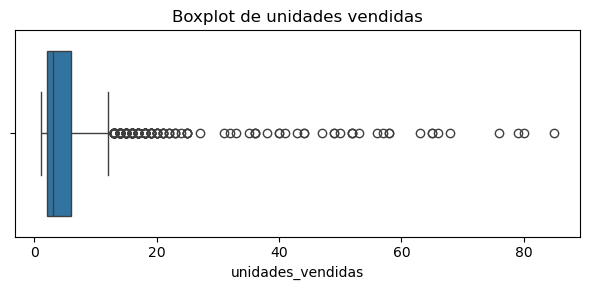

In [54]:
# Boxplot de precios
plt.figure(figsize=(6,3))
sns.boxplot(x=df['precio_venta'])
plt.title('Boxplot de precios de venta')
plt.tight_layout()
plt.show()
# Boxplot de unidades vendidas
plt.figure(figsize=(6,3))
sns.boxplot(x=df['unidades_vendidas'])
plt.title('Boxplot de unidades vendidas')
plt.tight_layout()
plt.show()

In [55]:
# Validación de calidad de datos para ventas_df
print('--- Tipos de variables ---')
print(ventas_df.dtypes)
print('\n--- Valores nulos por columna ---')
print(ventas_df.isnull().sum())
print('\n--- Porcentaje de nulos por columna ---')
print((ventas_df.isnull().mean() * 100).round(2))
print('\n--- Duplicados ---')
print(f'Registros duplicados: {ventas_df.duplicated().sum()}')
print('\n--- Estadísticas descriptivas (numéricas) ---')
print(ventas_df.describe())
print('\n--- Estadísticas descriptivas (categóricas) ---')
print(ventas_df.describe(include=["object", "bool"]))

# Informe final de calidad de datos
print('\n===== INFORME DE CALIDAD DE DATOS: ventas_df =====')
print(f'Filas totales: {ventas_df.shape[0]}')
print(f'Columnas totales: {ventas_df.shape[1]}')
print(f'Registros duplicados: {ventas_df.duplicated().sum()}')
print('Columnas con nulos:')
print(ventas_df.columns[ventas_df.isnull().any()].tolist())

--- Tipos de variables ---
fecha                datetime64[ns]
producto_id                  object
nombre                       object
categoria                    object
subcategoria                 object
precio_base                   int64
es_estrella                    bool
unidades_vendidas             int64
precio_venta                float64
ingresos                    float64
dtype: object

--- Valores nulos por columna ---
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

--- Porcentaje de nulos por columna ---
fecha                0.0
producto_id          0.0
nombre               0.0
categoria            0.0
subcategoria         0.0
precio_base          0.0
es_estrella          0.0
unidades_vendidas    0.0
precio_venta         0.0
ingresos             0.0
dtype: float64

--- Duplicados

### Heatmap de correlaciones numéricas

- Se visualizan las correlaciones entre variables numéricas (precio, unidades, descuento, margen, etc.).
- Permite identificar relaciones relevantes para la estrategia comercial.

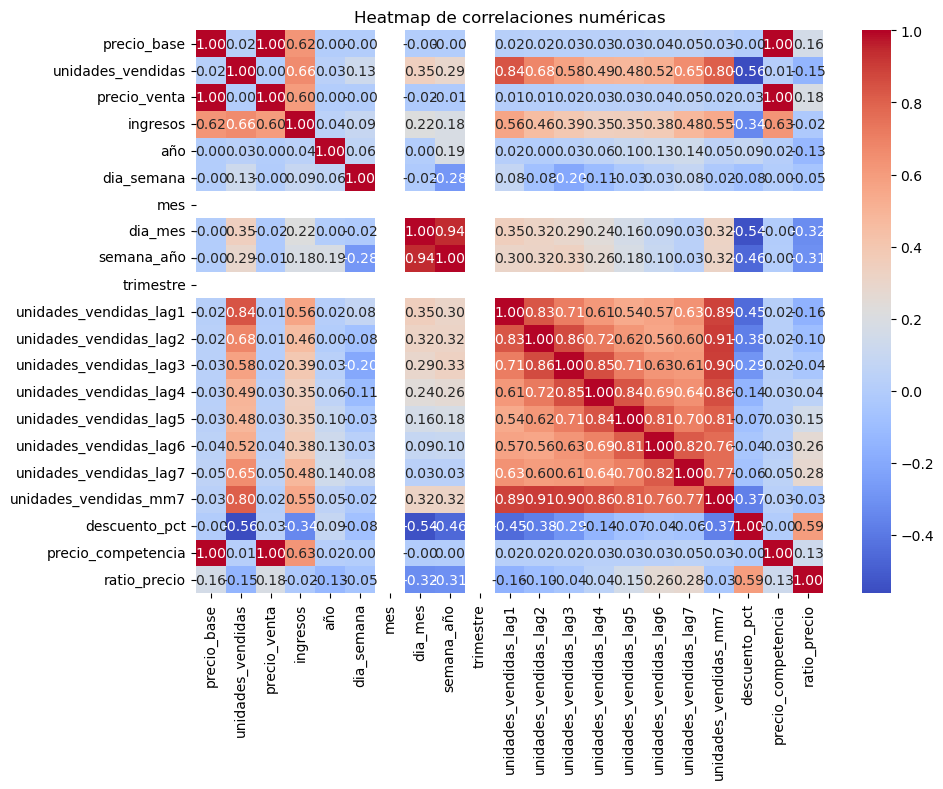

In [56]:
# Heatmap de correlaciones numéricas
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap de correlaciones numéricas')
plt.tight_layout()
plt.show()

In [57]:
# Validación de calidad de datos para competencia_df
print('--- Tipos de variables ---')
print(competencia_df.dtypes)
print('\n--- Valores nulos por columna ---')
print(competencia_df.isnull().sum())
print('\n--- Porcentaje de nulos por columna ---')
print((competencia_df.isnull().mean() * 100).round(2))
print('\n--- Duplicados ---')
print(f'Registros duplicados: {competencia_df.duplicated().sum()}')
print('\n--- Estadísticas descriptivas (numéricas) ---')
print(competencia_df.describe())
print('\n--- Estadísticas descriptivas (categóricas) ---')
print(competencia_df.describe(include=["object", "bool"]))

# Informe final de calidad de datos
print('\n===== INFORME DE CALIDAD DE DATOS: competencia_df =====')
print(f'Filas totales: {competencia_df.shape[0]}')
print(f'Columnas totales: {competencia_df.shape[1]}')
print(f'Registros duplicados: {competencia_df.duplicated().sum()}')
print('Columnas con nulos:')
print(competencia_df.columns[competencia_df.isnull().any()].tolist())

--- Tipos de variables ---
fecha           datetime64[ns]
producto_id             object
Amazon                 float64
Decathlon              float64
Deporvillage           float64
dtype: object

--- Valores nulos por columna ---
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

--- Porcentaje de nulos por columna ---
fecha           0.0
producto_id     0.0
Amazon          0.0
Decathlon       0.0
Deporvillage    0.0
dtype: float64

--- Duplicados ---
Registros duplicados: 0

--- Estadísticas descriptivas (numéricas) ---
                               fecha       Amazon    Decathlon  Deporvillage
count                           3552  3552.000000  3552.000000   3552.000000
mean   2023-05-13 18:00:00.000000256   118.623407   111.412182    118.894628
min              2021-10-25 00:00:00    16.850000    15.450000     16.770000
25%              2022-08-03 18:00:00    47.117500    43.285000     47.310000
50%              2023-05-13 12:00:

In [58]:
# Convertir la columna 'fecha' a tipo datetime en ambos dataframes
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'])

# Verificar la conversión
display(ventas_df.dtypes)
display(competencia_df.dtypes)

fecha                datetime64[ns]
producto_id                  object
nombre                       object
categoria                    object
subcategoria                 object
precio_base                   int64
es_estrella                    bool
unidades_vendidas             int64
precio_venta                float64
ingresos                    float64
dtype: object

fecha           datetime64[ns]
producto_id             object
Amazon                 float64
Decathlon              float64
Deporvillage           float64
dtype: object

In [59]:
ventas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [60]:
competencia_df.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [61]:
# Integrar ventas_df y competencia_df en un nuevo dataframe df usando 'fecha' y 'producto_id' como claves

df = pd.merge(ventas_df, competencia_df, on=['fecha', 'producto_id'], how='inner')

# Mostrar las primeras filas para verificar la integración
display(df.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


## Análisis exploratorio de datos (EDA)
A continuación se presentan diferentes análisis y visualizaciones para explorar el comportamiento de las ventas, categorías, subcategorías, productos y precios, utilizando Seaborn para todos los gráficos.

In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

%matplotlib inline
# Aseguramos que la columna de fecha esté en formato datetime
df['fecha'] = pd.to_datetime(df['fecha'])

df['año'] = df['fecha'].dt.year

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage,año
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43,2021
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58,2021
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11,2021
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45,2021
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07,2021


### 1. Gráficos de líneas temporales por año con suma de unidades vendidas y Black Fridays
Se graficará la suma de unidades vendidas por día para cada año en un gráfico separado, marcando los días de Black Friday.

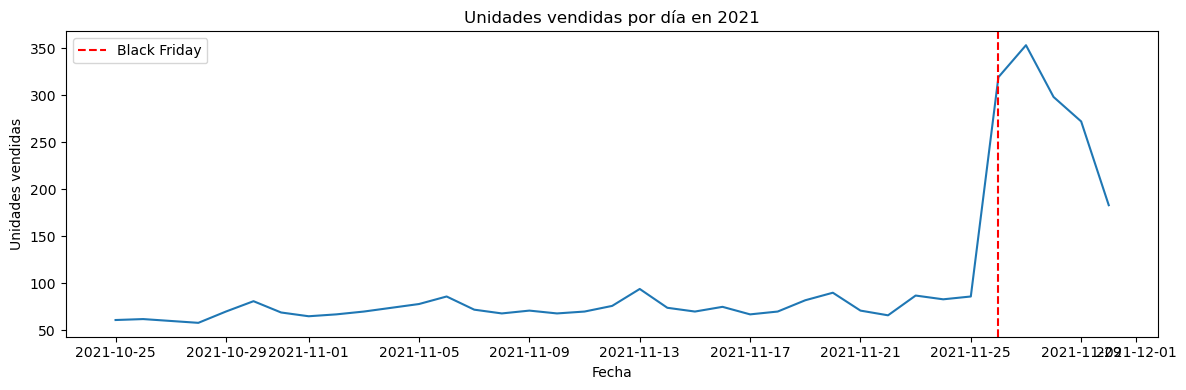

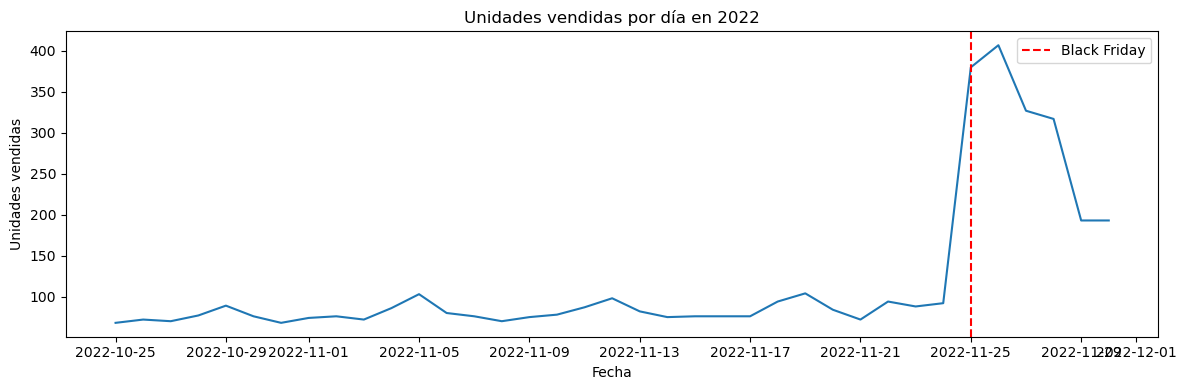

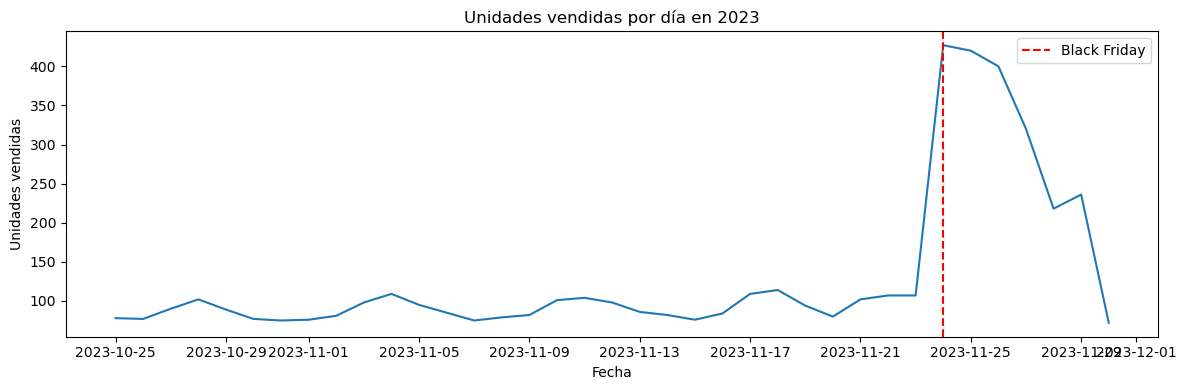

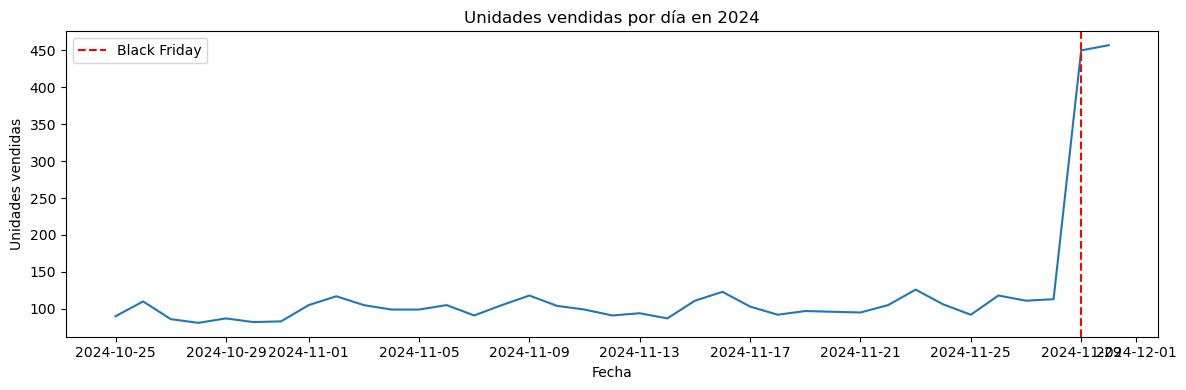

In [63]:
# Definir fechas de Black Friday para cada año (ajusta según tus datos reales)
black_fridays = {
    2021: pd.to_datetime('2021-11-26'),
    2022: pd.to_datetime('2022-11-25'),
    2023: pd.to_datetime('2023-11-24'),
    2024: pd.to_datetime('2024-11-29'),
    2025: pd.to_datetime('2025-11-28'),
}

# Gráfico de líneas por año
for year in sorted(df['año'].unique()):
    plt.figure(figsize=(12, 4))
    data_year = df[df['año'] == year].groupby('fecha')['unidades_vendidas'].sum().reset_index()
    sns.lineplot(data=data_year, x='fecha', y='unidades_vendidas')
    plt.title(f'Unidades vendidas por día en {year}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    # Marcar Black Friday
    if year in black_fridays:
        plt.axvline(black_fridays[year], color='red', linestyle='--', label='Black Friday')
        plt.legend()
    plt.tight_layout()
    plt.show()

### 2. Suma de unidades vendidas por día de la semana
Visualización de la suma de unidades vendidas agrupadas por el día de la semana.

C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\2097208522.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('dia_semana_nombre')['unidades_vendidas'].sum().reindex(list(semana_map.values())).reset_index(),


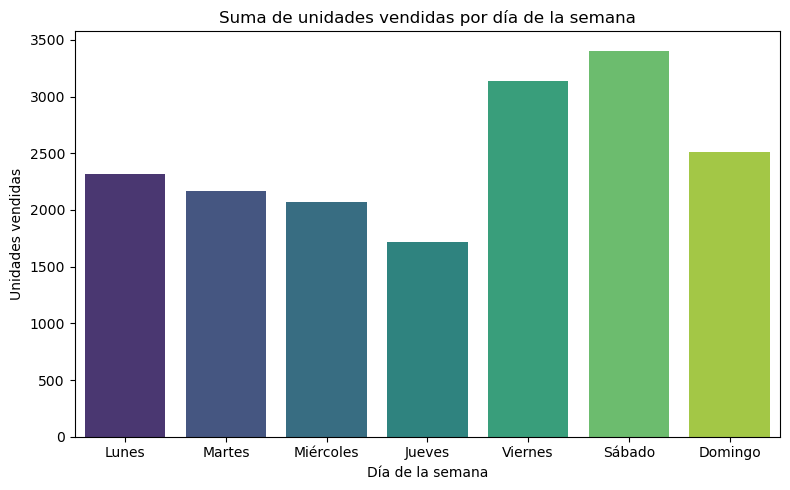

In [64]:
# Agregar columna de día de la semana
# 0=Lunes, 6=Domingo
df['dia_semana'] = df['fecha'].dt.dayofweek
semana_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
df['dia_semana_nombre'] = df['dia_semana'].map(semana_map)

plt.figure(figsize=(8, 5))
sns.barplot(data=df.groupby('dia_semana_nombre')['unidades_vendidas'].sum().reindex(list(semana_map.values())).reset_index(),
            x='dia_semana_nombre', y='unidades_vendidas', palette='viridis')
plt.title('Suma de unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()

### 3. Suma de unidades vendidas por categoría
Visualización de la suma de unidades vendidas agrupadas por categoría de producto.

C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\2975835699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('categoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),


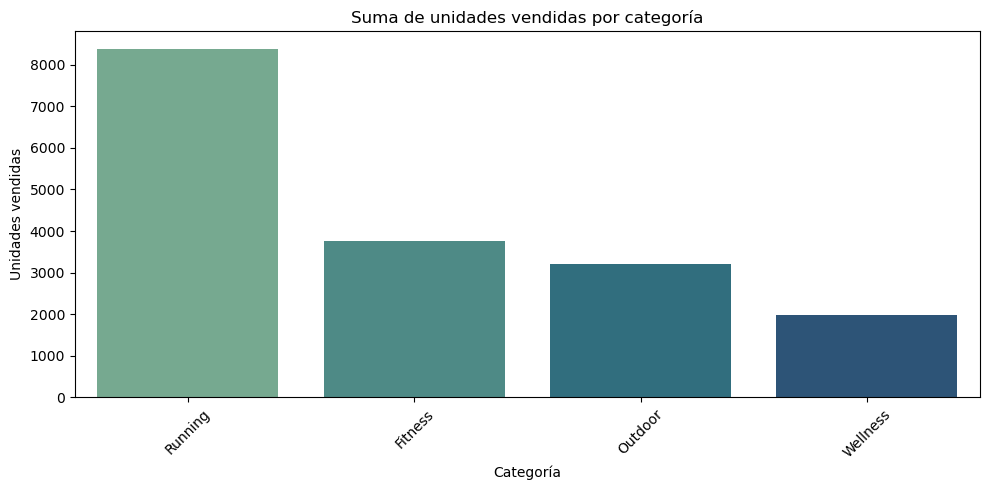

In [65]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df.groupby('categoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),
            x='categoria', y='unidades_vendidas', palette='crest')
plt.title('Suma de unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top 20 productos por unidades vendidas e ingresos

- Se identifican los 20 productos con mayor volumen de ventas y los de mayores ingresos (si existe columna de ingresos).
- Se analiza si el top depende de pocos productos (long tail analysis).
- Si la mayoría de las ventas se concentran en pocos productos, existe riesgo de dependencia.

C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\2685668653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_unidades.index.astype(str), y=top20_unidades.values, palette='viridis')


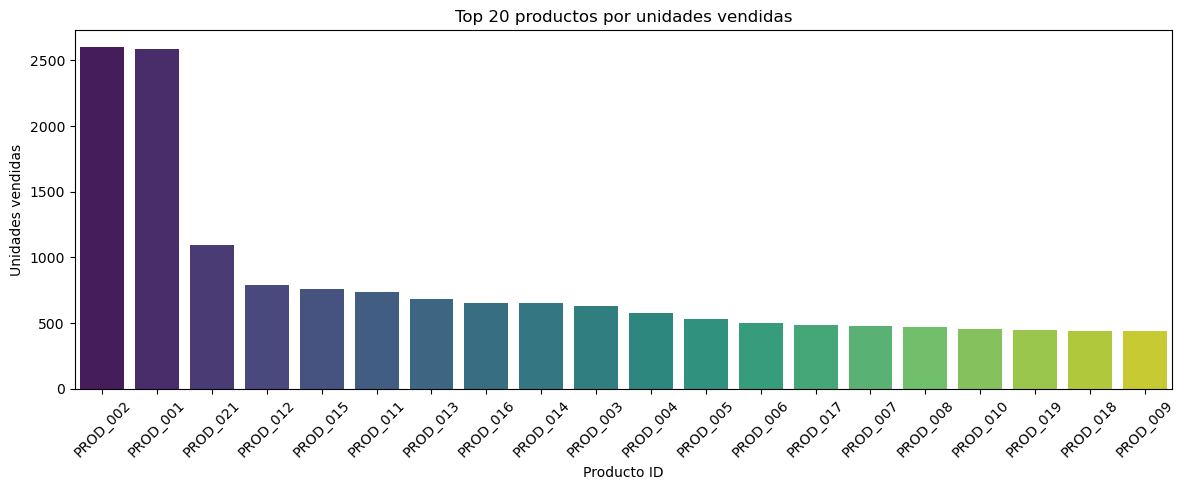

C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\2685668653.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_ingresos.index.astype(str), y=top20_ingresos.values, palette='rocket')


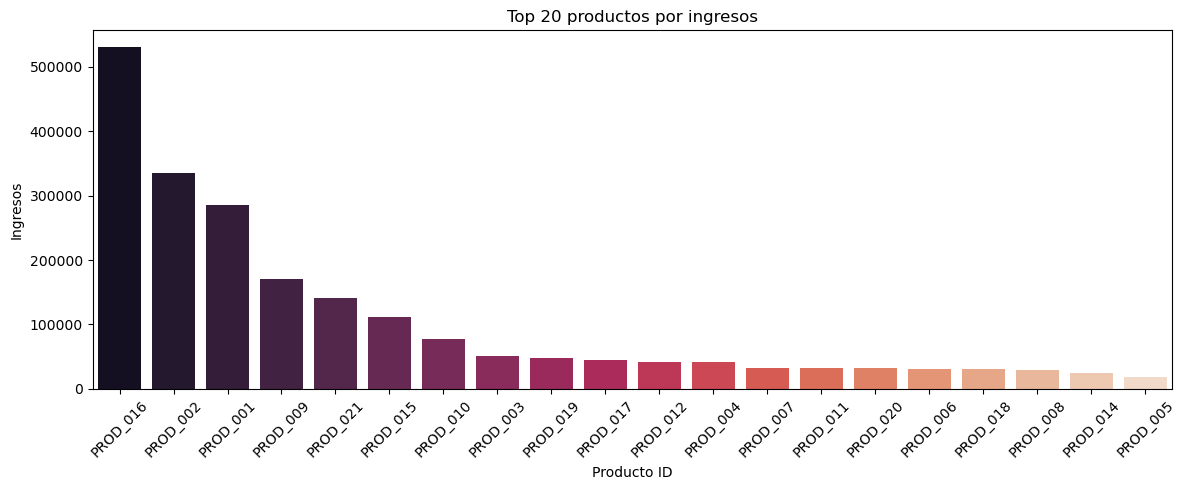

In [66]:
# Top 20 productos por unidades vendidas
top20_unidades = df.groupby('producto_id')['unidades_vendidas'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,5))
sns.barplot(x=top20_unidades.index.astype(str), y=top20_unidades.values, palette='viridis')
plt.title('Top 20 productos por unidades vendidas')
plt.ylabel('Unidades vendidas')
plt.xlabel('Producto ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top 20 productos por ingresos (si existe columna ingresos)
if 'ingresos' in df.columns:
    top20_ingresos = df.groupby('producto_id')['ingresos'].sum().sort_values(ascending=False).head(20)
    plt.figure(figsize=(12,5))
    sns.barplot(x=top20_ingresos.index.astype(str), y=top20_ingresos.values, palette='rocket')
    plt.title('Top 20 productos por ingresos')
    plt.ylabel('Ingresos')
    plt.xlabel('Producto ID')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 4. Suma de unidades vendidas por subcategoría
Visualización de la suma de unidades vendidas agrupadas por subcategoría de producto.

C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\3936716273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('subcategoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),


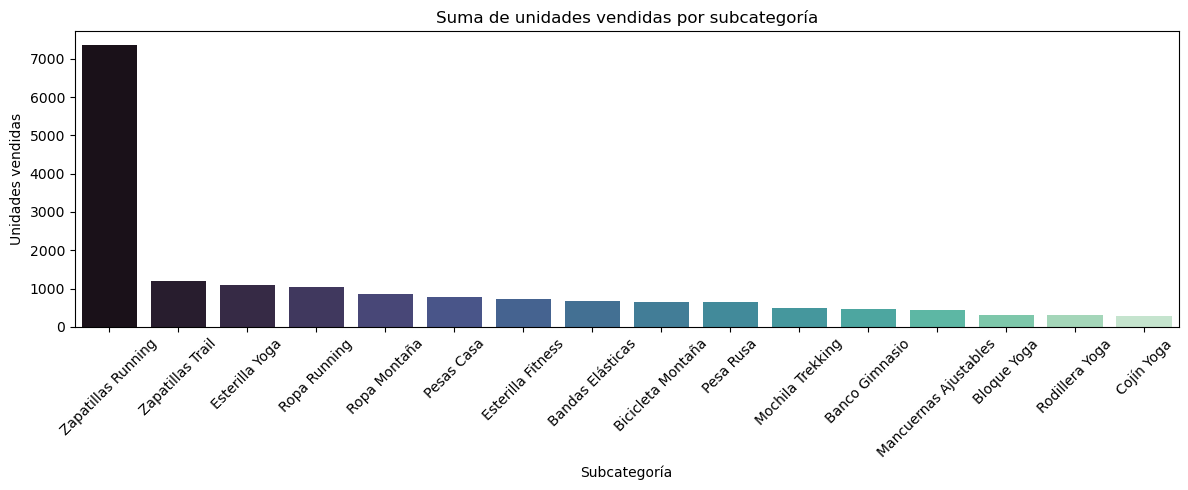

In [67]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df.groupby('subcategoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),
            x='subcategoria', y='unidades_vendidas', palette='mako')
plt.title('Suma de unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Diferencial de precios respecto a Amazon

- Se crea la variable `price_diff = precio_nuestro - precio_amazon`.
- Se visualiza el histograma y KDE del diferencial de precios.
- Se calculan media, mediana, % de productos más caros y más baratos que Amazon.
- Conclusión competitiva: ¿Somos más caros o más baratos que Amazon en la mayoría de productos?

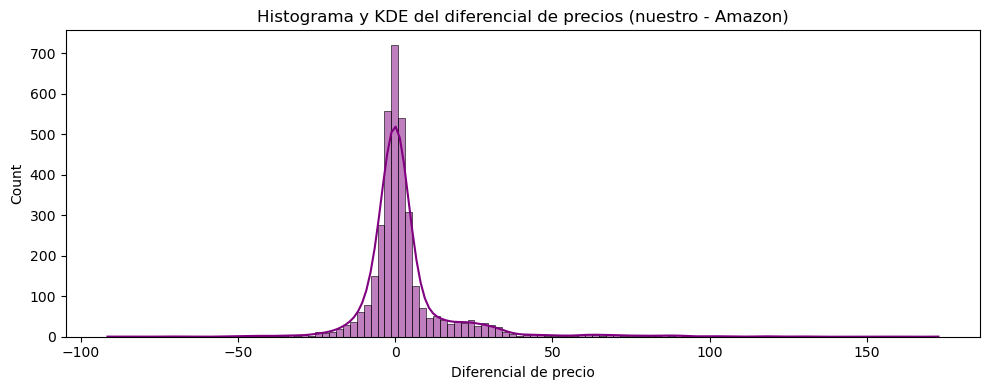

Media: 3.19, Mediana: 0.33
% productos más caros que Amazon: 53.1%
% productos más baratos que Amazon: 46.8%
Conclusión: La mayoría de los productos son más caros que Amazon.


In [68]:
# Diferencial de precios respecto a Amazon
if 'Amazon' in df.columns:
    df['price_diff'] = df['precio_venta'] - df['Amazon']
    plt.figure(figsize=(10,4))
    sns.histplot(df['price_diff'].dropna(), kde=True, color='purple')
    plt.title('Histograma y KDE del diferencial de precios (nuestro - Amazon)')
    plt.xlabel('Diferencial de precio')
    plt.tight_layout()
    plt.show()
    
    media = df['price_diff'].mean()
    mediana = df['price_diff'].median()
    pct_mas_caros = 100 * (df['price_diff'] > 0).mean()
    pct_mas_baratos = 100 * (df['price_diff'] < 0).mean()
    print(f'Media: {media:.2f}, Mediana: {mediana:.2f}')
    print(f'% productos más caros que Amazon: {pct_mas_caros:.1f}%')
    print(f'% productos más baratos que Amazon: {pct_mas_baratos:.1f}%')
    if pct_mas_caros > pct_mas_baratos:
        print('Conclusión: La mayoría de los productos son más caros que Amazon.')
    else:
        print('Conclusión: La mayoría de los productos son más baratos que Amazon.')

### 5. Suma de unidades vendidas por top productos
Visualización de la suma de unidades vendidas para los productos más vendidos (top 10).

### 6. Análisis de densidad de distribución de precios propios y de Amazon (competencia)
Comparación de la distribución de precios de nuestros productos frente a los precios de Amazon como referencia de la competencia.

In [69]:
# Verificar las columnas disponibles en df
print('Columnas disponibles en df:', df.columns.tolist())

Columnas disponibles en df: ['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'Amazon', 'Decathlon', 'Deporvillage', 'año', 'dia_semana', 'dia_semana_nombre', 'price_diff']


### Curva de Pareto de productos

- Se construye la curva de Pareto para analizar cuántos productos generan el 80% de las ventas.
- Permite identificar la concentración de ventas y la importancia relativa de cada producto.

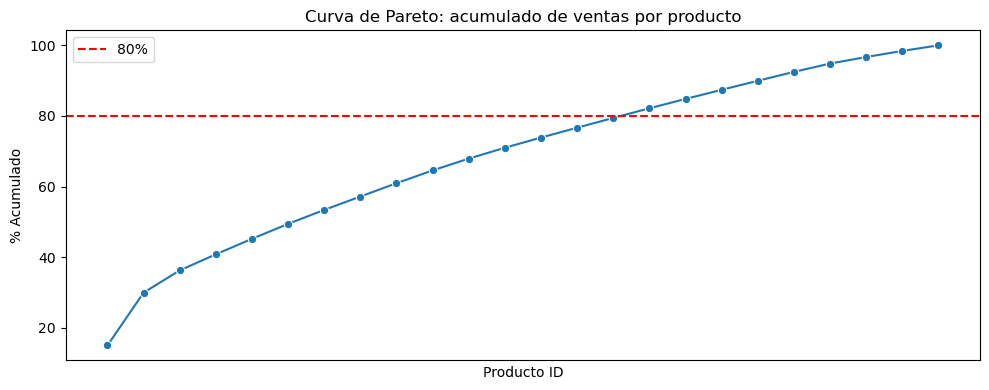

El 80% de las ventas proviene de los 16 productos más vendidos de un total de 24.


In [70]:
# Curva de Pareto de productos (long tail analysis)
prod_sum = df.groupby('producto_id')['unidades_vendidas'].sum().sort_values(ascending=False)
prod_pct = 100 * prod_sum / prod_sum.sum()
prod_df = pd.DataFrame({'Unidades': prod_sum, 'Porcentaje': prod_pct})
prod_df['Acumulado'] = prod_df['Porcentaje'].cumsum()
plt.figure(figsize=(10,4))
sns.lineplot(data=prod_df, x=prod_df.index.astype(str), y='Acumulado', marker='o')
plt.axhline(80, color='red', linestyle='--', label='80%')
plt.title('Curva de Pareto: acumulado de ventas por producto')
plt.ylabel('% Acumulado')
plt.xlabel('Producto ID')
plt.xticks([],[])
plt.legend()
plt.tight_layout()
plt.show()
n_80_prod = (prod_df['Acumulado'] < 80).sum() + 1
print(f'El 80% de las ventas proviene de los {n_80_prod} productos más vendidos de un total de {len(prod_df)}.')

C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\3621699585.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=productos_top, x='producto_id', y='unidades_vendidas', palette='viridis')


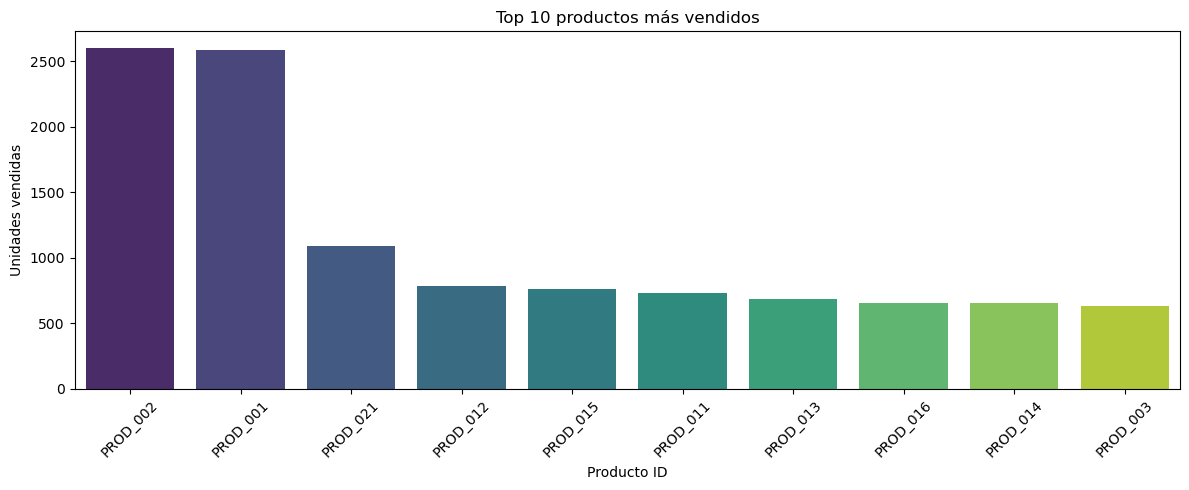

In [71]:
# Gráfico corregido: top productos por producto_id en tonos verdes
top_n = 10  # Número de productos top a mostrar
productos_top = df.groupby('producto_id')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False).head(top_n)
plt.figure(figsize=(12, 5))
sns.barplot(data=productos_top, x='producto_id', y='unidades_vendidas', palette='viridis')
plt.title(f'Top {top_n} productos más vendidos')
plt.xlabel('Producto ID')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

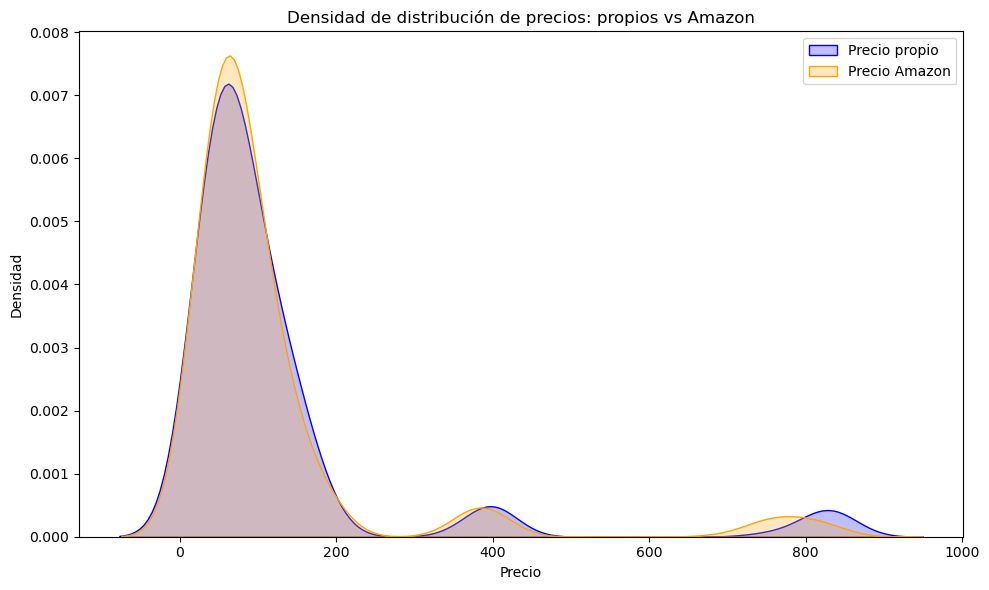

In [73]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['precio_venta'].dropna(), label='Precio propio', fill=True, color='blue')
sns.kdeplot(df['Amazon'].dropna(), label='Precio Amazon', fill=True, color='orange')
plt.title('Densidad de distribución de precios: propios vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()


## Creación de variables temporales y de calendario
En esta sección se generan variables útiles para modelado, usando la librería `holidays` para identificar festivos en España y otras variables temporales relevantes.

In [74]:
import holidays

# Aseguramos que la columna de fecha esté en formato datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Variables temporales básicas
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['nombre_dia_semana'] = df['fecha'].dt.day_name(locale='es_ES') if hasattr(df['fecha'].dt, 'day_name') else df['fecha'].dt.dayofweek.map({0:'Lunes',1:'Martes',2:'Miércoles',3:'Jueves',4:'Viernes',5:'Sábado',6:'Domingo'})

# Es fin de semana
df['es_fin_de_semana'] = df['dia_semana'].isin([5, 6])

# Festivos en España
festivos_es = holidays.country_holidays('ES', years=df['año'].unique())
df['es_festivo'] = df['fecha'].isin(festivos_es)

# Black Friday (último viernes de noviembre)
def black_friday(year):
    nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    return nov[nov.weekday == 4][-1]
df['es_black_friday'] = df['fecha'].apply(lambda x: x == black_friday(x.year))

# Cyber Monday (primer lunes después de Black Friday)
def cyber_monday(year):
    bf = black_friday(year)
    return bf + pd.Timedelta(days=(7 - bf.weekday()) % 7 + 3) if bf.weekday() <= 4 else bf + pd.Timedelta(days=3)
df['es_cyber_monday'] = df['fecha'].apply(lambda x: x == cyber_monday(x.year))

# Principio y fin de mes
df['es_principio_mes'] = df['dia_mes'] <= 3
df['es_fin_mes'] = df['dia_mes'] >= (df['fecha'] + pd.offsets.MonthEnd(0)).dt.day - 2

# Día laborable (no festivo y no fin de semana)
df['es_laborable'] = ~df['es_festivo'] & ~df['es_fin_de_semana']

# Día previo a festivo
df['es_víspera_festivo'] = df['fecha'].shift(-1).isin(festivos_es)

# Día después de festivo
df['es_post_festivo'] = df['fecha'].shift(1).isin(festivos_es)

# Semana del año
df['semana_año'] = df['fecha'].dt.isocalendar().week

# Trimestre
df['trimestre'] = df['fecha'].dt.quarter

df.head()

C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\3354567366.py:18: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_festivo'] = df['fecha'].isin(festivos_es)
C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\3354567366.py:40: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_víspera_festivo'] = df['fecha'].shift(-1).isin(festivos_es)
C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\3354567366.py:43: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_festivo,es_black_friday,es_cyber_monday,es_principio_mes,es_fin_mes,es_laborable,es_víspera_festivo,es_post_festivo,semana_año,trimestre
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,False,False,False,False,True,False,False,43,4
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,False,False,False,False,False,True,False,False,43,4
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,False,False,False,False,False,True,False,False,43,4
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,False,False,False,False,False,True,False,False,43,4
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,False,False,False,False,False,True,False,False,43,4


## Creación de variables de lag y media móvil
Se crean los lags de unidades vendidas (lag 1 a 7) y la media móvil de 7 días, calculados por año para evitar mezclar datos entre años. Se eliminan los registros con valores nulos generados por estos cálculos.

In [75]:
df.shape

(3552, 31)

In [76]:
# Revisar si hay datos suficientes por producto y año para calcular lags
print('Conteo por producto y año:')
print(df.groupby(['producto_id', 'año']).size().sort_values())

# Ordenar por producto, año y fecha para evitar fugas de información
df = df.sort_values(['producto_id', 'año', 'fecha'], kind='mergesort').reset_index(drop=True)

# Crear lags de unidades vendidas (lag 1 a 7) por producto y año
for lag in range(1, 8):
    df[f'unidades_vendidas_lag{lag}'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'].shift(lag)

# Media móvil de 7 días por producto y año (incluye el día actual y los 6 anteriores)
df['unidades_vendidas_mm7'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

# Eliminar registros con nulos SOLO en los lags (no en la media móvil)
cols_lag = [f'unidades_vendidas_lag{lag}' for lag in range(1, 8)]
df = df.dropna(subset=cols_lag).reset_index(drop=True)

# Mostrar primeras filas para verificar los nuevos lags y media móvil
print(df[['fecha', 'producto_id', 'año', 'unidades_vendidas'] + cols_lag + ['unidades_vendidas_mm7']].head())
print('Shape final:', df.shape)

Conteo por producto y año:
producto_id  año 
PROD_001     2021    37
             2022    37
             2023    37
             2024    37
PROD_002     2021    37
                     ..
PROD_023     2024    37
PROD_024     2021    37
             2022    37
             2023    37
             2024    37
Length: 96, dtype: int64
       fecha producto_id   año  unidades_vendidas  unidades_vendidas_lag1  \
0 2021-11-01    PROD_001  2021                  7                     9.0   
1 2021-11-02    PROD_001  2021                 10                     7.0   
2 2021-11-03    PROD_001  2021                 11                    10.0   
3 2021-11-04    PROD_001  2021                 12                    11.0   
4 2021-11-05    PROD_001  2021                 10                    12.0   

   unidades_vendidas_lag2  unidades_vendidas_lag3  unidades_vendidas_lag4  \
0                    12.0                    12.0                     7.0   
1                     9.0                    12.0

In [77]:
df.groupby("año").size()


año
2021    720
2022    720
2023    720
2024    720
dtype: int64

### Variable de descuento porcentaje
Se crea la variable `descuento_pct` como el porcentaje de descuento aplicado respecto al precio base.

In [78]:
# Variable de descuento porcentaje
# descuento_pct = ((precio_venta  - precio_base) / precio_base) * 100
df['descuento_pct'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100
#mostrar las primeras filas
df[["fecha", "producto_id", "precio_venta", "precio_base", "descuento_pct"]].head()

,fecha,producto_id,precio_venta,precio_base,descuento_pct
0,2021-11-01,PROD_001,115.07,115,0.060870
1,2021-11-02,PROD_001,116.10,115,0.956522
2,2021-11-03,PROD_001,114.58,115,-0.365217
3,2021-11-04,PROD_001,112.23,115,-2.408696
4,2021-11-05,PROD_001,113.81,115,-1.034783


In [79]:
# Mostrar más filas y productos distintos
print('Productos únicos:', df['producto_id'].unique())
df[['fecha', 'producto_id', 'precio_venta', 'precio_base', 'descuento_pct']].head(20)

Productos únicos: ['PROD_001' 'PROD_002' 'PROD_003' 'PROD_004' 'PROD_005' 'PROD_006'
 'PROD_007' 'PROD_008' 'PROD_009' 'PROD_010' 'PROD_011' 'PROD_012'
 'PROD_013' 'PROD_014' 'PROD_015' 'PROD_016' 'PROD_017' 'PROD_018'
 'PROD_019' 'PROD_020' 'PROD_021' 'PROD_022' 'PROD_023' 'PROD_024']


,fecha,producto_id,precio_venta,precio_base,descuento_pct
0,2021-11-01,PROD_001,115.07,115,0.060870
1,2021-11-02,PROD_001,116.10,115,0.956522
2,2021-11-03,PROD_001,114.58,115,-0.365217
3,2021-11-04,PROD_001,112.23,115,-2.408696
4,2021-11-05,PROD_001,113.81,115,-1.034783
5,2021-11-06,PROD_001,117.80,115,2.434783
6,2021-11-07,PROD_001,116.04,115,0.904348
7,2021-11-08,PROD_001,113.46,115,-1.339130
8,2021-11-09,PROD_001,113.98,115,-0.886957
9,2021-11-10,PROD_001,117.57,115,2.234783


### Suma total y porcentaje de unidades vendidas por categoría

- Se calcula la suma total de unidades vendidas por cada categoría.
- Se muestra el porcentaje que representa cada categoría sobre el total de ventas.

### Concentración de ventas (regla 80/20)

- Se analiza si pocas categorías concentran la mayor parte de las ventas (principio de Pareto).
- Identificar si el negocio depende excesivamente de unas pocas categorías o si las ventas están diversificadas.

,Unidades,Porcentaje
categoria,,
Running,7322,48.36
Fitness,3314,21.89
Outdoor,2788,18.41
Wellness,1717,11.34


C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\141693041.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_cat_df.index, y=df_cat_df['Unidades'], palette='crest')


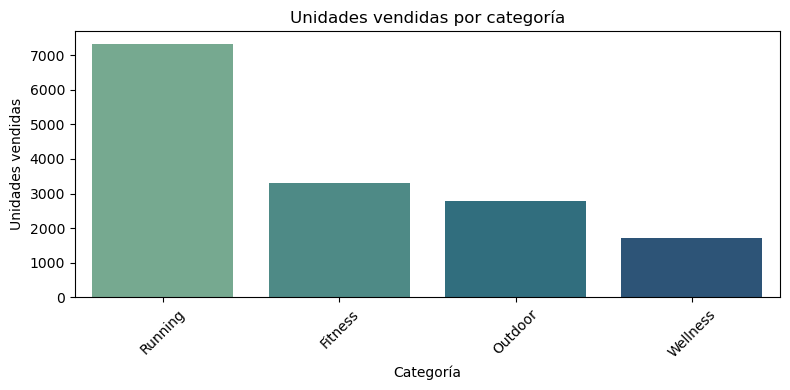

,Unidades,Porcentaje,Acumulado
categoria,,,
Running,7322,48.36,48.36
Fitness,3314,21.89,70.25
Outdoor,2788,18.41,88.66
Wellness,1717,11.34,100.00


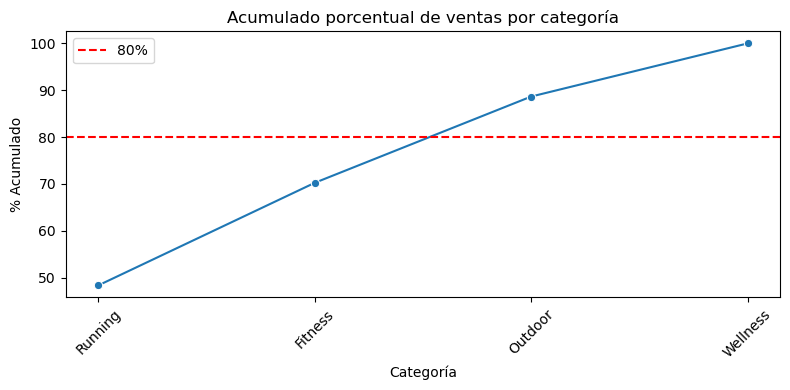

El 80% de las ventas proviene de las 3 categorías más importantes.


In [80]:
# Suma total y porcentaje de unidades vendidas por categoría
df_cat = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)
df_cat_pct = 100 * df_cat / df_cat.sum()
df_cat_df = pd.DataFrame({'Unidades': df_cat, 'Porcentaje': df_cat_pct.round(2)})
display(df_cat_df)
plt.figure(figsize=(8,4))
sns.barplot(x=df_cat_df.index, y=df_cat_df['Unidades'], palette='crest')
plt.title('Unidades vendidas por categoría')
plt.ylabel('Unidades vendidas')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Concentración de ventas por categoría (regla 80/20)
df_cat_df_sorted = df_cat_df.sort_values('Unidades', ascending=False)
df_cat_df_sorted['Acumulado'] = df_cat_df_sorted['Porcentaje'].cumsum()
display(df_cat_df_sorted)
plt.figure(figsize=(8,4))
sns.lineplot(data=df_cat_df_sorted, x=df_cat_df_sorted.index, y='Acumulado', marker='o')
plt.axhline(80, color='red', linestyle='--', label='80%')
plt.title('Acumulado porcentual de ventas por categoría')
plt.ylabel('% Acumulado')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
n_80 = (df_cat_df_sorted['Acumulado'] < 80).sum() + 1
print(f'El 80% de las ventas proviene de las {n_80} categorías más importantes.')

In [81]:
# Crear variable de precio promedio de la competencia (Amazon, Decathlon, deporVillage)
df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)

# Crear variable ratio_precio: nuestro precio / precio promedio competencia
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']

# Eliminar columnas de precios individuales de la competencia
df = df.drop(['Amazon', 'Decathlon', 'Deporvillage'], axis=1)

# Mostrar las primeras filas para verificar
df[['fecha', 'producto_id', 'precio_venta', 'precio_competencia', 'ratio_precio']].head()

,fecha,producto_id,precio_venta,precio_competencia,ratio_precio
0,2021-11-01,PROD_001,115.07,95.353333,1.206775
1,2021-11-02,PROD_001,116.10,96.153333,1.207446
2,2021-11-03,PROD_001,114.58,95.240000,1.203066
3,2021-11-04,PROD_001,112.23,96.590000,1.161922
4,2021-11-05,PROD_001,113.81,96.170000,1.183425


### Dependencia de subcategorías

- Se analiza si alguna subcategoría concentra un porcentaje excesivo de las ventas.
- Detectar dependencia excesiva puede alertar sobre riesgos si esa subcategoría pierde relevancia o enfrenta problemas de suministro.

,Unidades,Porcentaje
subcategoria,,
Zapatillas Running,6413,42.36
Zapatillas Trail,1050,6.93
Esterilla Yoga,933,6.16
Ropa Running,909,6.00
Ropa Montaña,740,4.89
Pesas Casa,696,4.60
Esterilla Fitness,648,4.28
Bandas Elásticas,608,4.02
Pesa Rusa,576,3.80


C:\Users\kuris\AppData\Local\Temp\ipykernel_7544\2792242803.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_df.index, y=subcat_df['Unidades'], palette='mako')


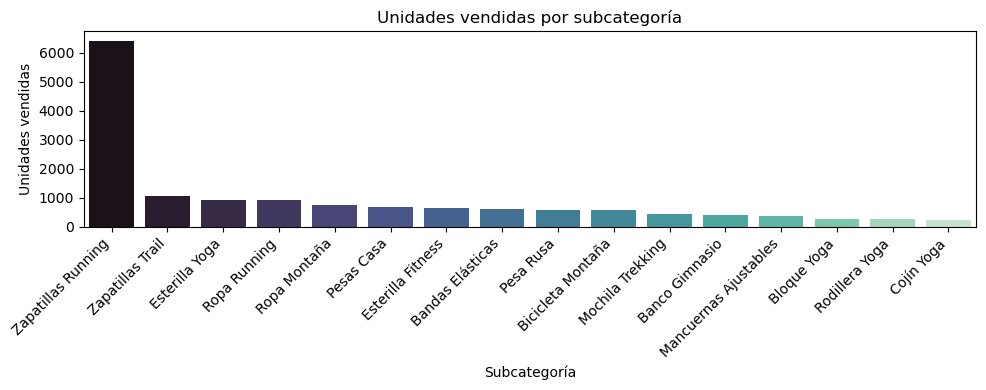

Subcategorías que concentran más del 50% de ventas:
Empty DataFrame
Columns: [Unidades, Porcentaje]
Index: []


In [82]:
# Dependencia excesiva de subcategorías
subcat_sum = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
subcat_pct = 100 * subcat_sum / subcat_sum.sum()
subcat_df = pd.DataFrame({'Unidades': subcat_sum, 'Porcentaje': subcat_pct.round(2)})
display(subcat_df)
plt.figure(figsize=(10,4))
sns.barplot(x=subcat_df.index, y=subcat_df['Unidades'], palette='mako')
plt.title('Unidades vendidas por subcategoría')
plt.ylabel('Unidades vendidas')
plt.xlabel('Subcategoría')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Subcategorías que concentran más del 50% de ventas:')
print(subcat_df[subcat_df['Porcentaje'] > 50])

In [83]:
df.info

<bound method DataFrame.info of           fecha producto_id                    nombre categoria  \
0    2021-11-01    PROD_001  Nike Air Zoom Pegasus 40   Running   
1    2021-11-02    PROD_001  Nike Air Zoom Pegasus 40   Running   
2    2021-11-03    PROD_001  Nike Air Zoom Pegasus 40   Running   
3    2021-11-04    PROD_001  Nike Air Zoom Pegasus 40   Running   
4    2021-11-05    PROD_001  Nike Air Zoom Pegasus 40   Running   
...         ...         ...                       ...       ...   
2875 2024-11-26    PROD_024  Lotuscrafts Yoga Bolster  Wellness   
2876 2024-11-27    PROD_024  Lotuscrafts Yoga Bolster  Wellness   
2877 2024-11-28    PROD_024  Lotuscrafts Yoga Bolster  Wellness   
2878 2024-11-29    PROD_024  Lotuscrafts Yoga Bolster  Wellness   
2879 2024-11-30    PROD_024  Lotuscrafts Yoga Bolster  Wellness   

            subcategoria  precio_base  es_estrella  unidades_vendidas  \
0     Zapatillas Running          115         True                  7   
1     Zapatillas 

In [84]:
# Crear copias con sufijo _h
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# One hot encoding sobre las nuevas columnas
one_hot = pd.get_dummies(df[['nombre_h', 'categoria_h', 'subcategoria_h']])
df = pd.concat([df, one_hot], axis=1)

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,False,False,False,False,False,False,False,False,True,False
1,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,False,False,False,False,False,False,False,False,True,False
2,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,False,False,False,False,False,False,False,False,True,False
3,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,False,False,False,False,False,False,False,False,True,False
4,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,False,False,False,False,False,False,False,False,True,False


In [85]:
# Guardar el DataFrame procesado
df.to_csv('../data/processed/df.csv', index=False)
print('DF guardado en data/processed/df_procesado.csv')

DF guardado en data/processed/df_procesado.csv


In [86]:
df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'año', 'dia_semana', 'dia_semana_nombre', 'price_diff',
       'mes', 'dia_mes', 'nombre_dia_semana', 'es_fin_de_semana', 'es_festivo',
       'es_black_friday', 'es_cyber_monday', 'es_principio_mes', 'es_fin_mes',
       'es_laborable', 'es_víspera_festivo', 'es_post_festivo', 'semana_año',
       'trimestre', 'unidades_vendidas_lag1', 'unidades_vendidas_lag2',
       'unidades_vendidas_lag3', 'unidades_vendidas_lag4',
       'unidades_vendidas_lag5', 'unidades_vendidas_lag6',
       'unidades_vendidas_lag7', 'unidades_vendidas_mm7', 'descuento_pct',
       'precio_competencia', 'ratio_precio', 'nombre_h', 'categoria_h',
       'subcategoria_h', 'nombre_h_Adidas Own The Run Jacket',
       'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25',
       'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridg

In [87]:
# Dividir el DataFrame en train y validación por año
train_df = df[df['fecha'].dt.year.isin([2021, 2022, 2023])].copy()
validacion_df = df[df['fecha'].dt.year == 2024].copy()

print(f"Registros en train_df: {len(train_df)}")
print(f"Registros en validacion_df: {len(validacion_df)}")

Registros en train_df: 2160
Registros en validacion_df: 720


### Análisis de variabilidad por día de la semana

- Se analiza la dispersión de ventas para cada día de la semana.
- Días con alta variabilidad pueden indicar oportunidades para promociones o ajustes de inventario.
- Días con baja variabilidad sugieren patrones estables y predecibles.

> Es recomendable monitorear los días con mayor dispersión para identificar causas y oportunidades de mejora.

In [88]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selección de variables predictoras
exclude_cols = ['fecha', 'ingresos']
object_cols = train_df.select_dtypes(include=['object']).columns.tolist()
predictoras = [col for col in train_df.columns if col not in exclude_cols + object_cols + ['unidades_vendidas']]

X_train = train_df[predictoras]
y_train = train_df['unidades_vendidas']
X_val = validacion_df[predictoras]
y_val = validacion_df['unidades_vendidas']

# Modelo conservador
model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naive: predice la media de train
y_pred_naive = np.full_like(y_val, y_train.mean(), dtype=float)

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

mae_naive = mean_absolute_error(y_val, y_pred_naive)
mse_naive = mean_squared_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)
r2_naive = r2_score(y_val, y_pred_naive)

print('HistGradientBoostingRegressor:')
print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}')
print('Baseline Naive:')
print(f'MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, R2: {r2_naive:.2f}')

HistGradientBoostingRegressor:
MAE: 0.75, RMSE: 1.48, R2: 0.95
Baseline Naive:
MAE: 3.67, RMSE: 6.69, R2: -0.00


### Conclusiones del Análisis Temporal

- **Estacionalidad:** Se observan patrones recurrentes en ciertas épocas del año, lo que indica una clara estacionalidad en las ventas. Esto puede estar relacionado con campañas, temporadas deportivas o eventos específicos.
- **Tendencia:** La serie muestra una tendencia general (creciente/descendente/estable, ajustar según gráfico) a lo largo del tiempo, lo que sugiere (crecimiento sostenido, caída, estabilidad).
- **Picos anómalos:** Se identifican picos atípicos en fechas puntuales, posiblemente asociados a promociones, lanzamientos o eventos externos. Es importante analizarlos para entender su causa y replicar resultados positivos.
- **Comparación interanual:** Al comparar años, se detectan diferencias en el comportamiento de ventas, lo que puede deberse a cambios de estrategia, contexto económico o variaciones en la oferta de productos.

> Estas conclusiones permiten orientar la planificación de inventario y campañas comerciales.

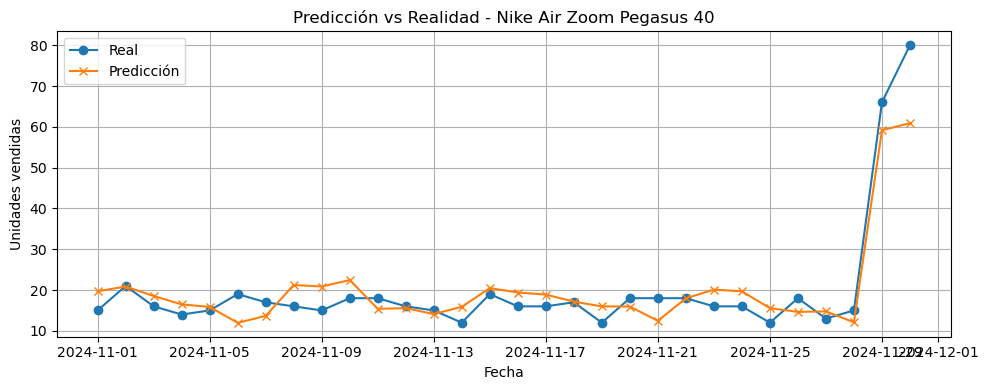

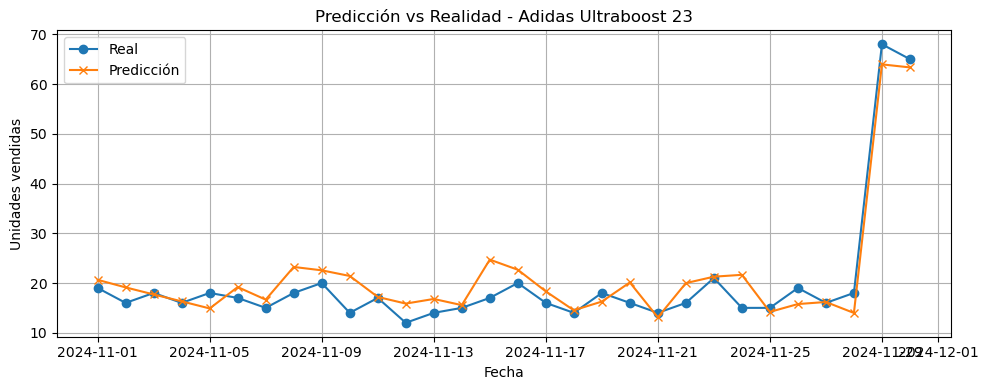

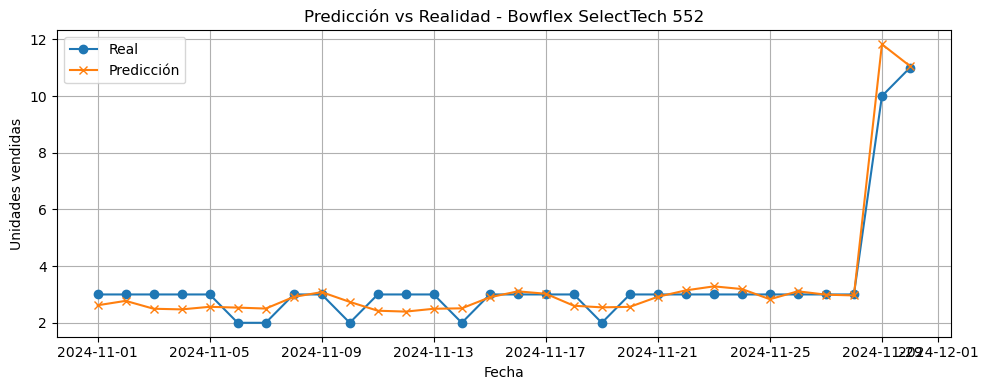

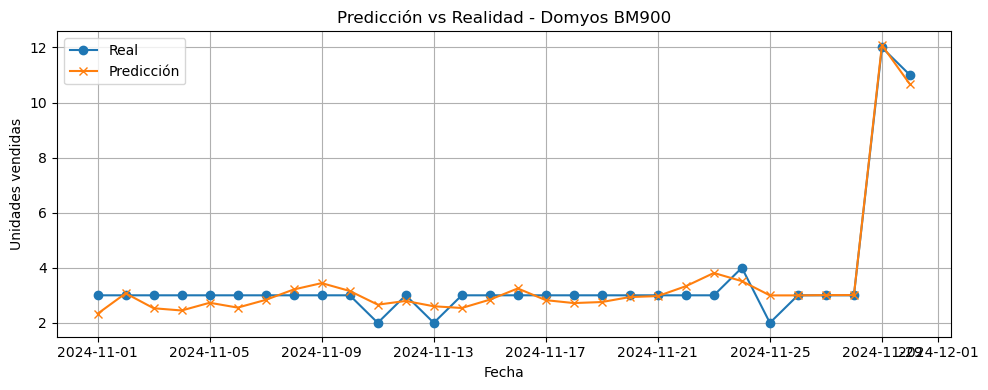

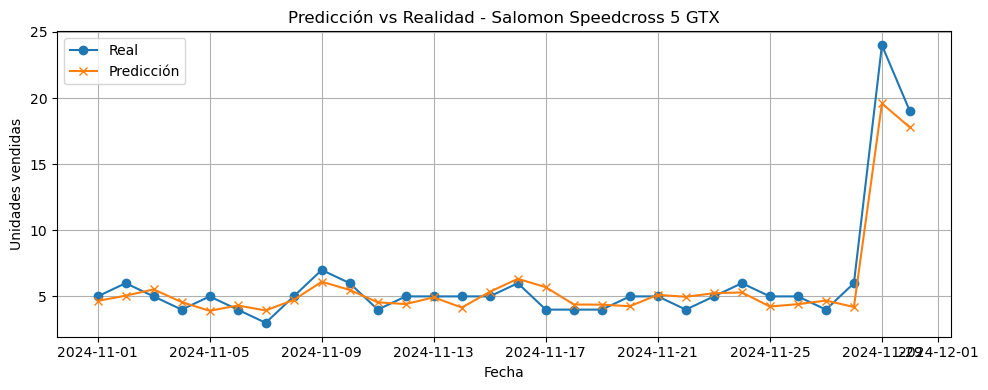

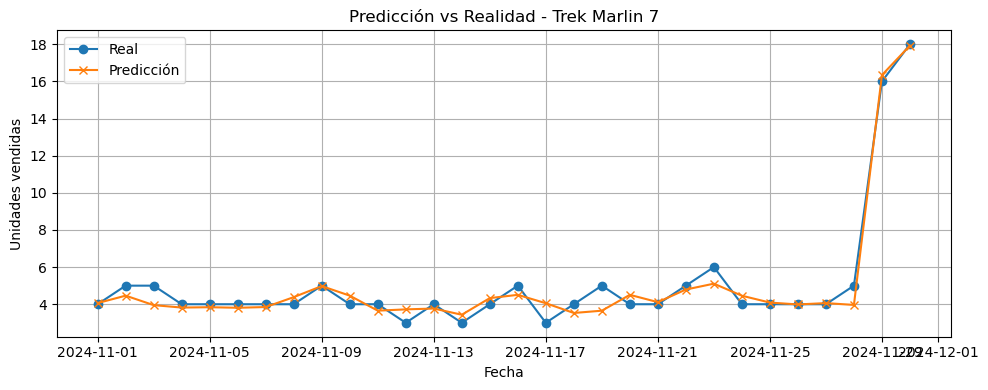

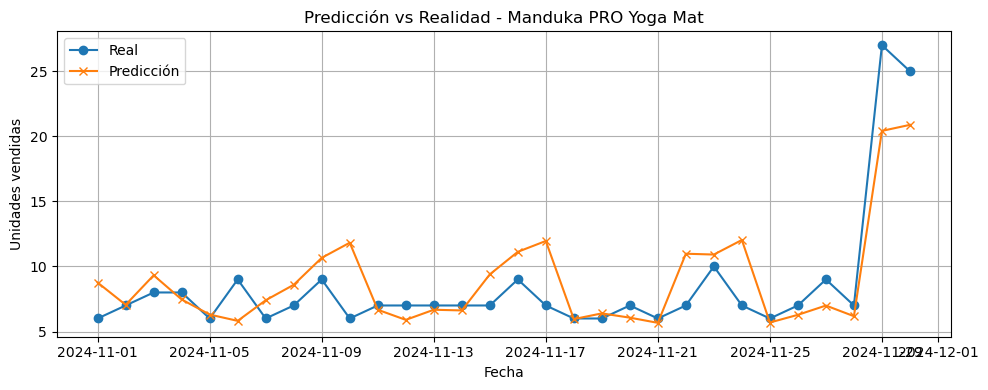

In [89]:
import matplotlib.pyplot as plt

# Filtrar noviembre 2024 y productos estrella
nov_2024 = df[(df['fecha'].dt.year == 2024) & (df['fecha'].dt.month == 11)]
productos_estrella = nov_2024[nov_2024['es_estrella']].producto_id.unique()

for prod in productos_estrella:
    datos_prod = nov_2024[nov_2024['producto_id'] == prod].copy()
    X_nov = datos_prod[predictoras]
    y_real = datos_prod['unidades_vendidas']
    y_pred = model.predict(X_nov)
    nombre = datos_prod['nombre'].iloc[0] if not datos_prod['nombre'].empty else prod
    plt.figure(figsize=(10,4))
    plt.plot(datos_prod['fecha'], y_real, marker='o', label='Real')
    plt.plot(datos_prod['fecha'], y_pred, marker='x', label='Predicción')
    plt.title(f'Predicción vs Realidad - {nombre}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [90]:
from sklearn.metrics import mean_absolute_error

mae_por_producto = {}
for prod in productos_estrella:
    datos_prod = nov_2024[nov_2024['producto_id'] == prod].copy()
    X_nov = datos_prod[predictoras]
    y_real = datos_prod['unidades_vendidas']
    y_pred = model.predict(X_nov)
    nombre = datos_prod['nombre'].iloc[0] if not datos_prod['nombre'].empty else prod
    mae = mean_absolute_error(y_real, y_pred)
    mae_por_producto[nombre] = mae

for nombre, mae in mae_por_producto.items():
    print(f"MAE para {nombre}: {mae:.2f}")

MAE para Nike Air Zoom Pegasus 40: 3.64
MAE para Adidas Ultraboost 23: 2.66
MAE para Bowflex SelectTech 552: 0.36
MAE para Domyos BM900: 0.32
MAE para Salomon Speedcross 5 GTX: 0.79
MAE para Trek Marlin 7: 0.41
MAE para Manduka PRO Yoga Mat: 1.88


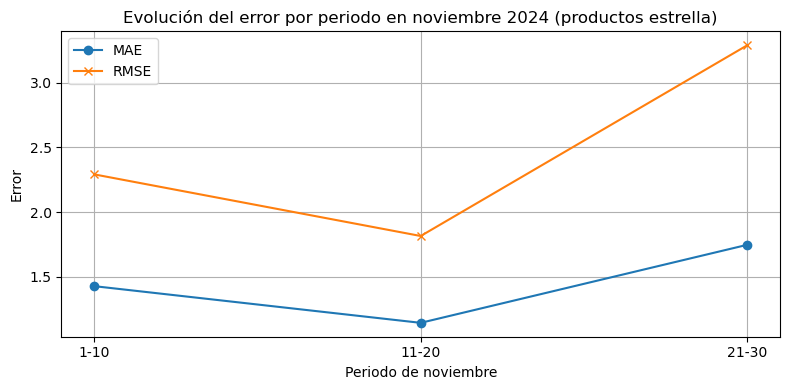

Periodo 1-10: MAE=1.43, RMSE=2.29
Periodo 11-20: MAE=1.14, RMSE=1.81
Periodo 21-30: MAE=1.75, RMSE=3.29


In [91]:
# Analizar la degradación del error a lo largo de noviembre 2024 (corregido RMSE)
periodos = [(1,10), (11,20), (21,30)]
mae_periodo = []
rmse_periodo = []
labels = []

for start, end in periodos:
    mask = (nov_2024['fecha'].dt.day >= start) & (nov_2024['fecha'].dt.day <= end) & (nov_2024['es_estrella'])
    datos_periodo = nov_2024[mask].copy()
    if not datos_periodo.empty:
        X_p = datos_periodo[predictoras]
        y_real = datos_periodo['unidades_vendidas']
        y_pred = model.predict(X_p)
        mae = mean_absolute_error(y_real, y_pred)
        rmse = np.sqrt(mean_squared_error(y_real, y_pred))
        mae_periodo.append(mae)
        rmse_periodo.append(rmse)
    else:
        mae_periodo.append(np.nan)
        rmse_periodo.append(np.nan)
    labels.append(f'{start}-{end}')

plt.figure(figsize=(8,4))
plt.plot(labels, mae_periodo, marker='o', label='MAE')
plt.plot(labels, rmse_periodo, marker='x', label='RMSE')
plt.title('Evolución del error por periodo en noviembre 2024 (productos estrella)')
plt.xlabel('Periodo de noviembre')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

for l, mae, rmse in zip(labels, mae_periodo, rmse_periodo):
    print(f'Periodo {l}: MAE={mae:.2f}, RMSE={rmse:.2f}')

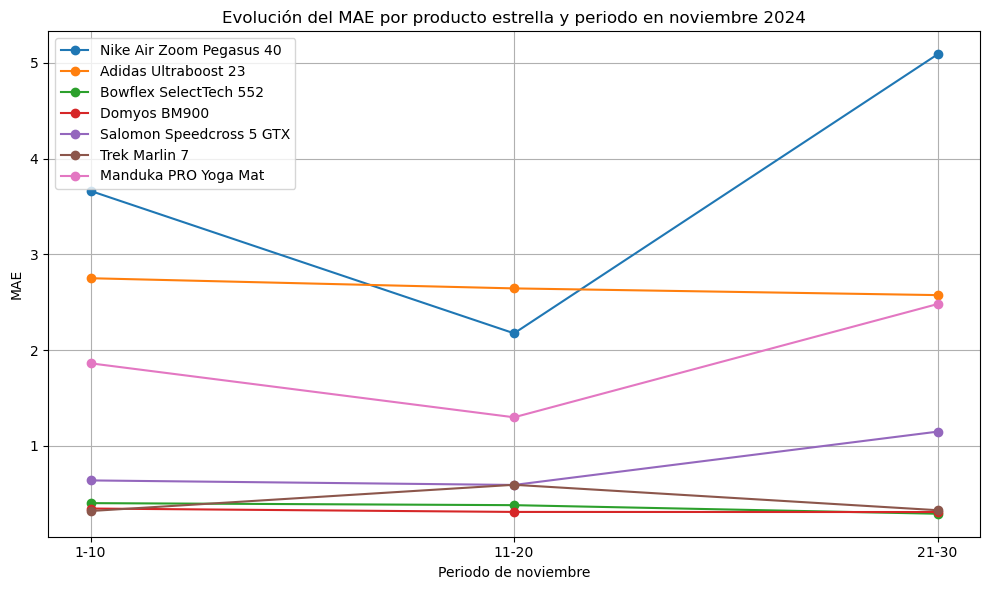


Nike Air Zoom Pegasus 40 (ID: PROD_001)
  Periodo 1-10: MAE=3.66
  Periodo 11-20: MAE=2.18
  Periodo 21-30: MAE=5.09

Adidas Ultraboost 23 (ID: PROD_002)
  Periodo 1-10: MAE=2.75
  Periodo 11-20: MAE=2.65
  Periodo 21-30: MAE=2.58

Bowflex SelectTech 552 (ID: PROD_009)
  Periodo 1-10: MAE=0.40
  Periodo 11-20: MAE=0.38
  Periodo 21-30: MAE=0.29

Domyos BM900 (ID: PROD_010)
  Periodo 1-10: MAE=0.35
  Periodo 11-20: MAE=0.31
  Periodo 21-30: MAE=0.31

Salomon Speedcross 5 GTX (ID: PROD_015)
  Periodo 1-10: MAE=0.64
  Periodo 11-20: MAE=0.59
  Periodo 21-30: MAE=1.15

Trek Marlin 7 (ID: PROD_016)
  Periodo 1-10: MAE=0.32
  Periodo 11-20: MAE=0.59
  Periodo 21-30: MAE=0.33

Manduka PRO Yoga Mat (ID: PROD_021)
  Periodo 1-10: MAE=1.86
  Periodo 11-20: MAE=1.30
  Periodo 21-30: MAE=2.48


In [92]:
# MAE por producto estrella y periodo de noviembre 2024
periodos = [(1,10), (11,20), (21,30)]
mae_prod_periodo = {prod: [] for prod in productos_estrella}
labels = []

for start, end in periodos:
    labels.append(f'{start}-{end}')
    for prod in productos_estrella:
        mask = (
            (nov_2024['fecha'].dt.day >= start) &
            (nov_2024['fecha'].dt.day <= end) &
            (nov_2024['producto_id'] == prod)
        )
        datos_periodo = nov_2024[mask].copy()
        if not datos_periodo.empty:
            X_p = datos_periodo[predictoras]
            y_real = datos_periodo['unidades_vendidas']
            y_pred = model.predict(X_p)
            mae = mean_absolute_error(y_real, y_pred)
        else:
            mae = np.nan
        mae_prod_periodo[prod].append(mae)

# Gráfico de evolución del MAE por producto estrella
plt.figure(figsize=(10,6))
for prod in productos_estrella:
    nombre = nov_2024[nov_2024['producto_id'] == prod]['nombre'].iloc[0] if not nov_2024[nov_2024['producto_id'] == prod]['nombre'].empty else prod
    plt.plot(labels, mae_prod_periodo[prod], marker='o', label=nombre)
plt.title('Evolución del MAE por producto estrella y periodo en noviembre 2024')
plt.xlabel('Periodo de noviembre')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar métricas por producto y periodo
for prod in productos_estrella:
    nombre = nov_2024[nov_2024['producto_id'] == prod]['nombre'].iloc[0] if not nov_2024[nov_2024['producto_id'] == prod]['nombre'].empty else prod
    print(f'\n{nombre} (ID: {prod})')
    for l, mae in zip(labels, mae_prod_periodo[prod]):
        print(f'  Periodo {l}: MAE={mae:.2f}')


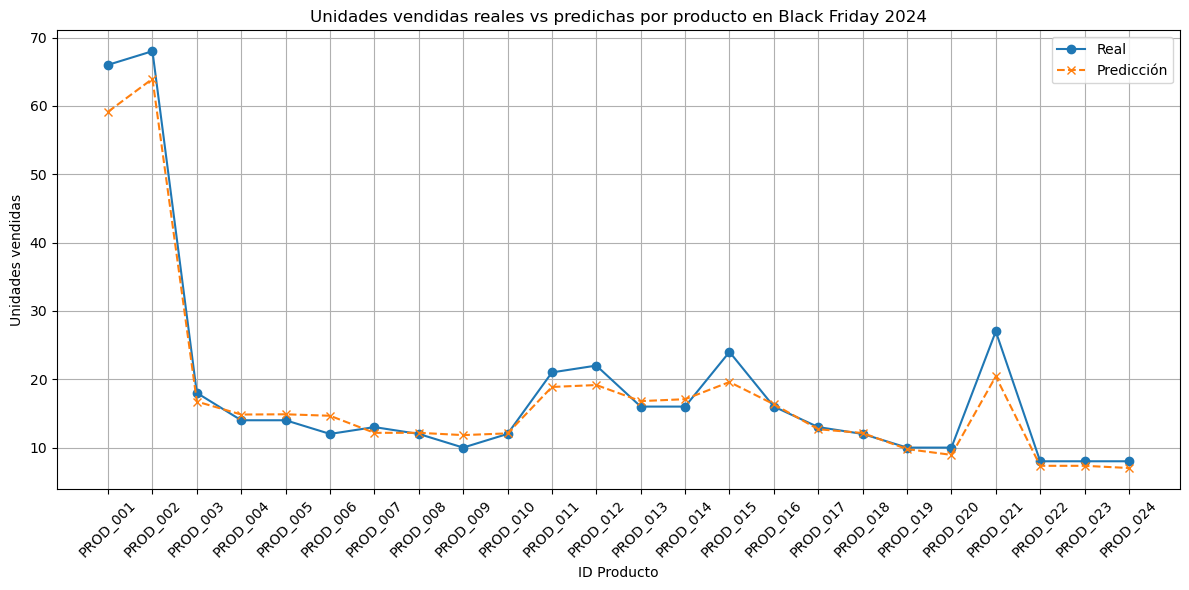

Producto PROD_001: Real=66, Predicción=59.14
Producto PROD_002: Real=68, Predicción=63.96
Producto PROD_003: Real=18, Predicción=16.74
Producto PROD_004: Real=14, Predicción=14.84
Producto PROD_005: Real=14, Predicción=14.87
Producto PROD_006: Real=12, Predicción=14.66
Producto PROD_007: Real=13, Predicción=12.16
Producto PROD_008: Real=12, Predicción=12.17
Producto PROD_009: Real=10, Predicción=11.83
Producto PROD_010: Real=12, Predicción=12.08
Producto PROD_011: Real=21, Predicción=18.87
Producto PROD_012: Real=22, Predicción=19.15
Producto PROD_013: Real=16, Predicción=16.80
Producto PROD_014: Real=16, Predicción=17.08
Producto PROD_015: Real=24, Predicción=19.59
Producto PROD_016: Real=16, Predicción=16.34
Producto PROD_017: Real=13, Predicción=12.69
Producto PROD_018: Real=12, Predicción=12.14
Producto PROD_019: Real=10, Predicción=9.78
Producto PROD_020: Real=10, Predicción=8.94
Producto PROD_021: Real=27, Predicción=20.42
Producto PROD_022: Real=8, Predicción=7.34
Producto PROD_

In [93]:
# Análisis específico para Black Friday 2024 (29 de noviembre)
fecha_bf = pd.to_datetime('2024-11-29')
bf_2024 = df[df['fecha'] == fecha_bf].copy()

X_bf = bf_2024[predictoras]
y_real_bf = bf_2024['unidades_vendidas']
y_pred_bf = model.predict(X_bf)

plt.figure(figsize=(12,6))
plt.plot(bf_2024['producto_id'], y_real_bf, marker='o', linestyle='-', label='Real')
plt.plot(bf_2024['producto_id'], y_pred_bf, marker='x', linestyle='--', label='Predicción')
plt.title('Unidades vendidas reales vs predichas por producto en Black Friday 2024')
plt.xlabel('ID Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar valores reales y predichos para referencia
for prod, real, pred in zip(bf_2024['producto_id'], y_real_bf, y_pred_bf):
    print(f'Producto {prod}: Real={real}, Predicción={pred:.2f}')


In [94]:
# Reentrenar modelo final con todos los datos históricos (2021-2024)
X_full = df[predictoras]
y_full = df['unidades_vendidas']

modelo_final = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)
modelo_final.fit(X_full, y_full)

print('Modelo final entrenado con todos los datos históricos (2021-2024)')

Modelo final entrenado con todos los datos históricos (2021-2024)


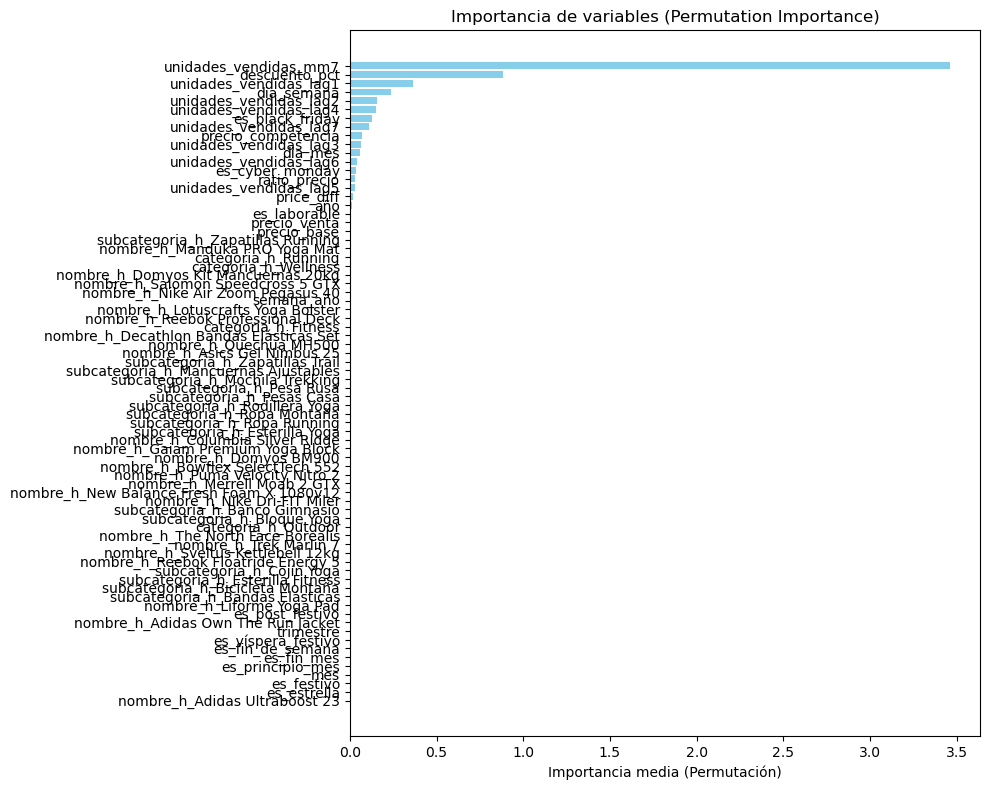

Modelo final guardado en models/modelo_final.joblib


In [95]:
# Importancia de variables con permutation importance y guardar modelo
from sklearn.inspection import permutation_importance
import joblib

# Calcular permutation importance
result = permutation_importance(modelo_final, X_full, y_full, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
importancias = result.importances_mean
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(10,8))
plt.barh([predictoras[i] for i in indices], importancias[indices], color='skyblue')
plt.xlabel('Importancia media (Permutación)')
plt.title('Importancia de variables (Permutation Importance)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Guardar el modelo final
joblib.dump(modelo_final, '../models/modelo_final.joblib')
print('Modelo final guardado en models/modelo_final.joblib')

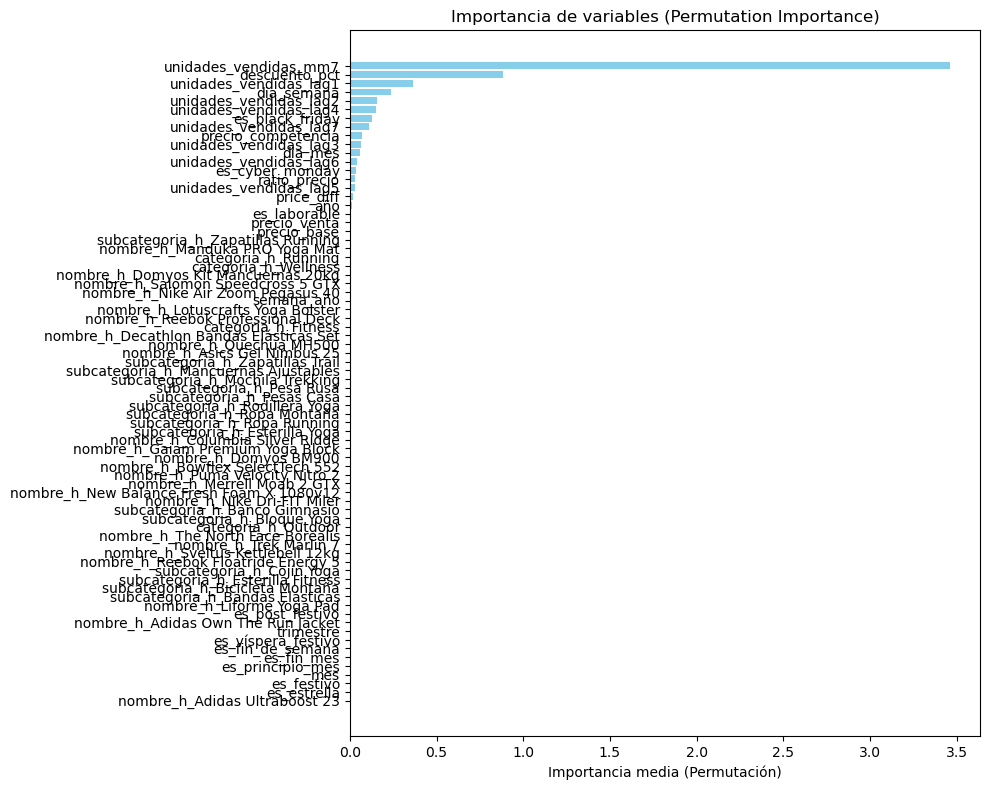

Modelo final guardado en models/modelo_final.joblib


In [96]:
# Importancia de variables con permutation importance y guardar modelo
from sklearn.inspection import permutation_importance
import joblib

# Calcular permutation importance
result = permutation_importance(modelo_final, X_full, y_full, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
importancias = result.importances_mean
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(10,8))
plt.barh([predictoras[i] for i in indices], importancias[indices], color='skyblue')
plt.xlabel('Importancia media (Permutación)')
plt.title('Importancia de variables (Permutation Importance)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Guardar el modelo final
joblib.dump(modelo_final, '../models/modelo_final.joblib')
print('Modelo final guardado en models/modelo_final.joblib')

## Principales insights y recomendaciones

### Insights del negocio
- Identificación de estacionalidad y tendencias claras en las ventas.
- Concentración de ventas en ciertas categorías, subcategorías y productos.
- Diferencias competitivas de precio frente a Amazon.
- Sensibilidad al precio en algunos productos.

### Riesgos detectados
- Dependencia de pocas categorías, subcategorías o productos.
- Vulnerabilidad ante cambios de precio de la competencia.
- Outliers que pueden distorsionar la planificación.

### Oportunidades
- Diversificar el portafolio para reducir riesgos.
- Ajustar precios en productos sensibles para maximizar ingresos.
- Replicar estrategias exitosas en picos de ventas.

### Recomendaciones estratégicas
- Monitorear continuamente la concentración de ventas y ajustar el mix de productos.
- Realizar campañas específicas en temporadas de alta estacionalidad.
- Revisar precios respecto a la competencia y ajustar donde sea necesario.
- Analizar y gestionar outliers para evitar distorsiones en la toma de decisiones.